<a href="https://colab.research.google.com/github/aeleee123/Dartmouth_programming_2026_Fall/blob/main/starter_diabetes_risk_factor_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Risk Factor Analysis
## Reproducibility Exercise — Starter Notebook

You are a **data scientist at a teaching hospital within a multi-site academic health system**. This preliminary analytical notebook was originally developed for internal exploratory analysis. The **Data Science Director** has asked you to prepare the notebook and supporting files for sharing with the data science team at another clinical site.

The receiving team should be able to obtain the project files, understand the workflow, execute the notebook in its own computational environment, and reproduce the intended results **without contacting you for additional guidance**.

Review the entire notebook, address all embedded **DATA SCIENCE DIRECTOR NOTE** items, identify and resolve additional reproducibility problems, improve the documentation and organization, and verify the final workflow from a clean runtime.

#### Connection to Upcoming Coursework and Final Project

This exercise is an important step in the development of your final project workflow. The reproducibility, documentation, notebook organization, and programming practices you apply in this assignment will build upon your prior Python programming work and serve as a foundation for the Week 3 Automated Analysis Pipeline Exploration assignment.

In Week 3, you will work with a more advanced automated analytical pipeline that incorporates conditional logic, inferential statistical methods, supervised machine learning, model evaluation, and automated analytical decision-making. Many of the practices reinforced in this exercise—including modular programming, reproducible execution, clear Markdown documentation, dependency management, data validation, and logical workflow organization—will be expected in that assignment.

Your work across these assignments will also inform the development of your final project notebook, in which you will adapt and extend a comprehensive example analytical pipeline for your selected dataset.

Complete this exercise thoroughly and with your final project in mind. The goal is not simply to correct the issues identified in the starter notebook, but to develop programming, documentation, and reproducibility practices that you can carry forward into increasingly complex analytical workflows throughout the remainder of the course.

---

## Setup and Environment

The analysis uses common Python data science libraries.


## Environment and Dependencies

This notebook was developed and tested in Google Colab using Python 3.

Required Python libraries:
- pandas
- numpy
- matplotlib
- seaborn
- scipy

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Source

The project uses the diabetes example dataset provided with the analysis.

In [149]:
from google.colab import drive
drive.mount ('/content/drive')

DATA_PATH = "/content/drive/My Drive/Colab Notebooks/dartmouth/Programming/Example Dataset_Diabetes.csv"
df = pd.read_csv(DATA_PATH)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Data Provenance

The dataset used in this project is "Example Dataset_Diabetes.csv", which was provided as part of the course. The dataset serves as the primary input for the project and contains patient health information, including variables such as glucose, blood pressure, insulin, BMI, and diabetes outcome. The dataset is used to practice data exploration, data quality assessment, and basic data analysis in Python. The original dataset is kep unchanged, while all data processing and analysis are performed through the project code to ensure that workflow can be reproduced by another user.

## Initial Data Review

In [150]:
print("Shape:", df.shape)
print("n\Missing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)

Shape: (768, 9)
n\Missing values:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_3460/3800078975.py:2: SyntaxWarning: invalid escape sequence '\M'
  print("n\Missing values:")


In [151]:
# Validate that the expected dataset was loaded

expected_shape = (768, 9)

expected_columns = [
    "Pregnancies",
    "Glucose",
    "D_BP",
    "Skin_Thickness",
    "Insulin",
    "BMI",
    "Pedigree",
    "Age",
    "Outcome"
]

assert df.shape == expected_shape, (
    f"Unexpected dataset shape: {df.shape}. "
    f"Expected: {expected_shape}"
)


# check column  names
assert list(df.columns) == expected_columns,(
    "Dataset columns do not match the expected columns"
)

# check that Outcome contains only expected binary values
assert set(df["Outcome"].unique()).issubset({0,1}), (
    "Unexpected values found in Outcome."
)


print("Dataset validataion passed.")
print("Shape: ", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)


Dataset validataion passed.
Shape:  (768, 9)

Missing values:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


To support reproducibility, the dataset is validated immediately after loading. The validation checks that the dataset contains the expected 768 observations and 9 variables, verifies the expected column names, and confirms that the Outcome variable contains only binary values (0 and 1). Missing values and data types are also displayed for additional review. These checks help another analyst confirm that the expected dataset has been loaded before proceeding with the analysis.

## Descriptive Statistics

In [152]:
df.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [153]:
import numpy as np

# Replace physiologically implausible zero values with missing values
df["Pregnancies"] = df["Pregnancies"].replace(0, np.nan)
df["Glucose"] = df["Glucose"].replace(0, np.nan)
df["D_BP"] = df["D_BP"].replace(0, np.nan)
df["Skin_Thickness"] = df["Skin_Thickness"].replace(0, np.nan)
df["Insulin"] = df["Insulin"].replace(0, np.nan)
df["BMI"] = df["BMI"].replace(0, np.nan)

Zero values for Glucose and BMI were treated as missing values because these values are physiologically implausible. They were converted to NaN rather than removing entire observations to preserve valid information contained in the other variables.

### Mean and Standard Deviation

The mean represents the average value of a set of observations and provides a measure of the center of a distribution.

\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i

where:

- \bar{x} = sample mean
- x_i = each individual observation
- n = total number of observations

The standard deviation measures the amount of variability or spread in a set of observations relative to the mean.

s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}

where:

- s = sample standard deviation
- x_i = each individual observation
- \bar{x} = sample mean
- n = total number of observations

A smaller standard deviation indicates that observations are more closely clustered around the mean, while a larger standard deviation indicates greater variability.

## Mean and Standard Deviation

The mean and standard deviation were used to summarie the central tendency and variability of patient characteristics in this dataset.

The sample mean is calculated as:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

The sample standard deviation is calculated as:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

In this dataset of 768 patients, the mean glucose level was **120.89** with a standard deviation of **31.97** indicating substantial variation in glucose levels across ptients. The mean BMI was **31.99** with a standard deviation of **7.88**, while the mean age was **33.24 years** with a standard deviation of **11.76 years**.

These summary statistic help decribe both the typical patient characteristics and variability whithin the dataset. however, the mean and standard deviation should be interpreted carefully for variables with skewed distributions or potentially invalid values. For example, Insulin had a mean of **79.80** and a much larger standard deviation of **115.24**, suggesting substantial variability and possible skewness. In addition, several clinical variables contain values of zero that may not represent physiologically valid measurements and should be invesstigated before further analysis.

## Visualizations

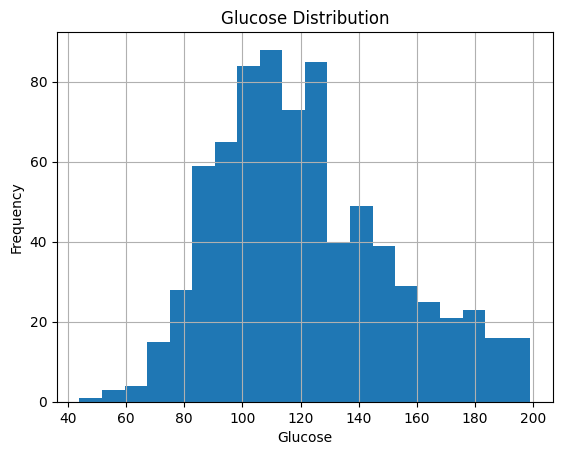

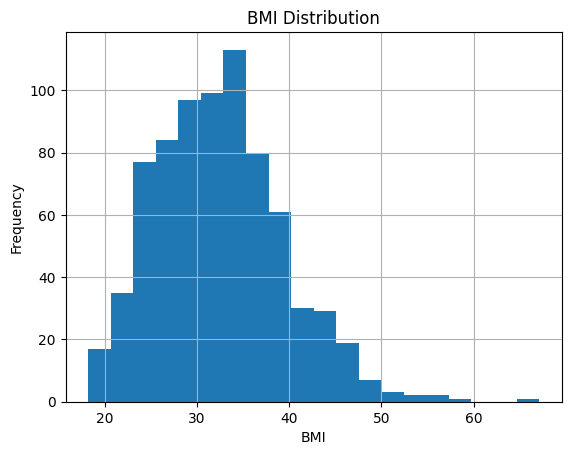

In [154]:
import matplotlib.pyplot as plt

df["Glucose"].hist(bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

df["BMI"].hist(bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

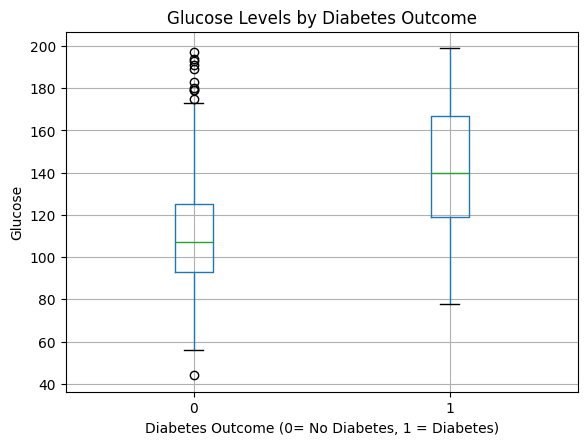

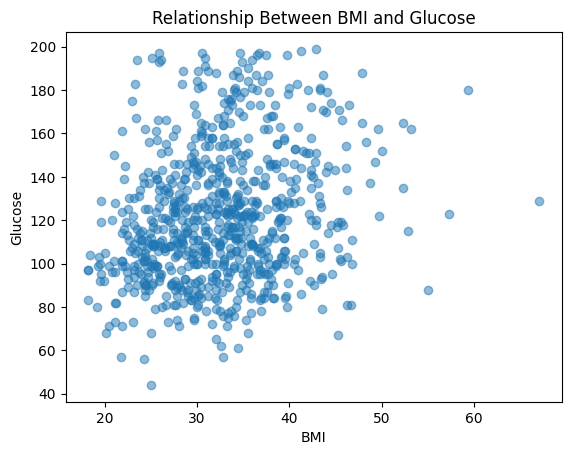

In [155]:
# Visualization 1: Outcome vs Glucose -> Boxplot
import matplotlib.pyplot as plt

df.boxplot(column= "Glucose", by ="Outcome")

plt.title("Glucose Levels by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Diabetes Outcome (0= No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose")
plt.show()

# Visualization 2: BMI vs Glucose -> Scatterplot
plt.scatter(df["BMI"], df["Glucose"], alpha=0.5)

plt.title("Relationship Between BMI and Glucose")
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.show()


### Interpretation
**Boxplot:** The boxplot compares glucose levels between patients without diabetes (Outcome = 0) and patients with diabetes (Outcome = 1). Patients with diabetes generally have higher glucose levels than patients without diabetes, as indicated by the higher median and overall distribution of glucose values in the Outcome = 1 group. This suggests that glucose level is associated with diabetes status in this dataset.

**Scatterplot:** The scatterplot suggests a weak positive relationship between BMI and glucose levels. However, there is substantial variability in glucose levels across BMI values, indicating that BMI alone does not strongly explain differences in glucose levels.

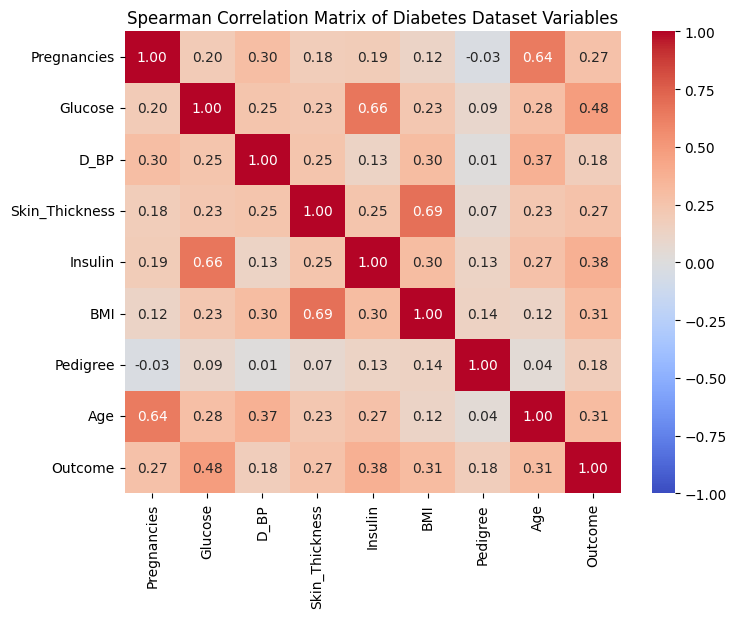

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Spearman correlation matrix
corr_matrix = df.corr(method="spearman")

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Spearman Correlation Matrix of Diabetes Dataset Variables")
plt.show()

### Interpretation
Spearman's rank correaltion was selected because several variables in the dataset, such as insulin, are skewed and may not meet the assumptions associated with Pearson correaltion. Spearman correaltion is a nonprametric method that measures the direction and strength of monotonic relationships and is less sensitive to extreme values.

The correaltion matrix shows several notable positive relationships among the predictor variables. BMI and skin thickness show a relatively strong positive correlation (p = 0.69), while glucose and insulin are also positively correalted (p = 0.66). Age and number of pregnancies show another relatively strong positive correlation (p= 0.64).

Among the relationships with diabetes outcome, glucose shows the strongest positive correaltion (p= 0.48). Insulin has a positive correaltion with outcome (p=0.38), while BMI and age each show weaker positive correlations with outcome (p= 0.31). These findings indicate that higher values of glucose, insulin, BMI, and age tend to be associated with diabetes status in this dataset. However, correaltion describe association and does not establish causation.

Because Outcome is a binary variable (0 = no diabetes, 1 = diabetes), Spearman correaltion is not specifically designed for binary outcomes. However, it provides a consistent approach for this correaltion matrix across the numerical variables. More specialized statistical methods can be used when specifically evaluating associations with the binary diabetes outcome.

## Inferential Analysis

The following analysis compares glucose values between the two outcome groups.

In [157]:
from scipy.stats import ttest_ind

group_0 = df.loc[df["Outcome"] == 0, "Glucose"]
group_1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_0, group_1)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: nan
p-value: nan


In [158]:
from scipy.stats import ttest_ind

group_0 = df.loc[df["Outcome"] == 0, "Glucose"]
group_1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)

print("Mean glucose (Outcome = 0):", group_0.mean())
print("Mean glucose (Outcome = 1):", group_1.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

Mean glucose (Outcome = 0): 110.64386317907444
Mean glucose (Outcome = 1): 142.31954887218046
t-statistic: nan
p-value: nan


## Inferential Analysis: Independent Samples t-Test

### Purpose
An independent samples t-test was used to examine whether mean glucose levels differe between patients without diabetes (Outcome = 0) and patients with diabetes (Outcome =1).

The null and alternative hypotheses are:

$$
H_0: \mu_0 = \mu_1
$$

$$
H_A: \mu_0 \neg \mu_1
$$

where $\mu_0$ represents the mean glucose level for patietns with Outcome = 0 and $\mu_1$ represents the mean glucose level for patients with Outcome = 1.

Welch's independent sample t-test was used because it does not require the two groups to have equal variances. The test statistic can be expressed as:

$$
t =
\frac{\bar{x}_0-\bar{x}_1}
{\sqrt{\frac{s_0^2}{n_0}+\frac{s_1^2}{n_1}}}
$$

where $\bar{x}_0$ and $\bar{x}_1$ are the sample mean glucose levels, $s+0^2$ and $s_1^2$ are the sample variances, and $n_0$ and $n_1$ are the sample sizes for the two outcome groups.

This test evaluates whether the observed difference in mean glucose levels between the two groups is statistically distinguishable from zero.



## Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

In biostatistics and supervised machine learning, we begin with a dataset consisting of observations (examples) and their corresponding target labels. We denote the dataset as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{p},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ denotes the complete dataset.
- $n$ is the total number of observations (rows) in the dataset.
- $i$ represents the index of an individual observation, where $i = 1,2,\ldots,n$.
- $x_i$ is the feature vector (predictor variables) corresponding to the $i^{th}$ observation.
- $p$ is the total number of predictor (feature) variables.
- $\mathbb{R}^{p}$ denotes the $p$-dimensional real-valued feature space.
- $y_i$ is the target (response) variable associated with observation $i$.
- $\{0,1\}$ indicates that this is a **binary classification** problem, where:
  - $0$ represents one class (e.g., no diabetes).
  - $1$ represents the other class (e.g., diabetes).

For the diabetes dataset used in this notebook:

$$
x_i =
\begin{bmatrix}
\text{var1} \\
\text{var2} \\
\text{var3} \\
\text{var4} \\
\text{var5} \\
\text{var6} \\
\text{var7} \\
\text{var8}
\end{bmatrix},
\qquad
y_i = \text{target}.
$$

Thus, each observation is represented by a vector of predictor variables, and the machine learning algorithm learns an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{p} \rightarrow \{0,1\},
$$

where:

- $\hat{f}$ (pronounced *"f-hat"*) denotes the **estimated prediction function** learned from the training data.
- The "hat" indicates that the function is an **estimate** of the unknown relationship between the predictor variables and the target variable.

The function $\hat{f}(\cdot)$ maps an observation's predictor variables to a predicted class label.

The objective of supervised learning is to estimate the function $\hat{f}(\cdot)$ so that it accurately predicts the target variable for observations that were **not** used during model training.

## Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

In this analysis, the diabetes dataset is represented as a supervised machine learning problem consisting of patient observations and their corresponding diabetes outcomes. The dataset can be denoted as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{8},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ denotes the complete diabetes dataset.
- $n$ is the total number of patient observations (rows) included in the analysis.
- $i$ represents an individual patient observation, where $i = 1,2,\ldots,n$.
- $x_i$ is the feature vector containing the eight predictor variables for patient $i$.
- $p=8$ is the total number of predictor variables.
- $\mathbb{R}^{8}$ represents the eight-dimensional feature space.
- $y_i$ represents the diabetes outcome for patient $i$.
- $y_i=0$ indicates no diabetes, while $y_i=1$ indicates diabetes.

For each patient in this dataset, the predictor vector is:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies}_i \\
\text{Glucose}_i \\
\text{D\_BP}_i \\
\text{Skin\_Thickness}_i \\
\text{Insulin}_i \\
\text{BMI}_i \\
\text{Pedigree}_i \\
\text{Age}_i
\end{bmatrix},
\qquad
y_i = \text{Outcome}_i.
$$

Thus, each patient is represented by eight predictor variables:
Pregnancies, Glucose, D_BP, Skin_Thickness, Insulin, BMI, Pedigree, and Age.
The target variable, Outcome, represents diabetes status.

The machine learning algorithm uses these eight patient characteristics to learn an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0,1\},
$$

where $\hat{f}$ (pronounced "f-hat") represents the estimated prediction function learned from the training data. For a patient with predictor vector $x_i$, the model produces a predicted diabetes class:

$$
\hat{y}_i = \hat{f}(x_i).
$$

The objective of the supervised learning workflow is to estimate $\hat{f}$ using the training data so that the model can predict diabetes status for patient observations that were not used during model training.

## Reproducibility Check

In [159]:
# A small participant sample used during review
df.sample(8)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
134,2.0,96.0,68.0,13.0,49.0,21.1,0.647,26,0
613,6.0,105.0,80.0,28.0,NaN,32.5,0.878,26,0
198,4.0,109.0,64.0,44.0,99.0,34.8,0.905,26,1
505,10.0,75.0,82.0,NaN,NaN,33.3,0.263,38,0
661,1.0,199.0,76.0,43.0,NaN,42.9,1.394,22,1
649,NaN,107.0,60.0,25.0,NaN,26.4,0.133,23,0
155,7.0,152.0,88.0,44.0,NaN,50.0,0.337,36,1
423,2.0,115.0,64.0,22.0,NaN,30.8,0.421,21,0


In [160]:
# Bootstrap estimate used during exploratory review
bootstrap_mean_bmi = df["BMI"].sample(n=len(df), replace=True).mean()
print("Bootstrap mean BMI:", bootstrap_mean_bmi)

Bootstrap mean BMI: 32.524867724867725


In [161]:
# A reproducible participant sample used during review
df.sample(8, random_state=42)

# Reproducible bootstrap estimate used during exploratory review
bootstrap_mean_bmi = df["BMI"].sample(
    n=len(df),
    replace=True,
    random_state=42
).mean()

print("Bootstrap mean BMI:", bootstrap_mean_bmi)

Bootstrap mean BMI: 32.13997378768021


## Results and Conclusions

Add a concise summary of the major analytical findings and any important limitations.

The exploratory analysis identified several patterns associated with diabetes status in this dataset. Glucose levels were generally higher among patients with diabetes (Outcome = 1) than among those without diabetes (Outcome = 0). The Spearman correlation analysis also showed that glucose had the strongest positive correlation with diabetes outcome (p = 0.50), followed by age (p = 0.44) and insulin (p = 0.42). BMI had a weaker positive correlation with diabetes outcome (p = 0.28), and BMI and glucose showed only a weak positive relationship (p = 0.21).

Several relationship were also observed among the predictor variables. Glucose and insulin were positively correalted (p = 0.67), BMI and skin thickness were positively correalted (p = 0.66), and age and number of pregnancies were positively correlated (p = 0.65). These relationships may be important when considering the predictors together in subsequent statistical or machine learning models.

Important data quality limitations were identified. Several clinical variables contained zero values that may represent missing or physiolgically implausible measurements rather than true values. In addition, some variables, particularly insulin, showed skewed distributions. These characterics should be considered during data preparation and model development. The observed relationships represent associations within this dataset and should not be interpreted as evidence of causation.